In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib

Using matplotlib backend: agg


In [26]:
df = pd.read_csv(r'/content/Symptom2Disease.csv')
df

,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."
...,...,...,...
1195,295,diabetes,I'm shaking and trembling all over. I've lost ...
1196,296,diabetes,"Particularly in the crevices of my skin, I hav..."
1197,297,diabetes,I regularly experience these intense urges and...
1198,298,diabetes,"I have trouble breathing, especially outside. ..."


In [27]:
df.shape

(1200, 3)

In [28]:
df.columns

Index(['Unnamed: 0', 'label', 'text'], dtype='object')

In [29]:
df.isna().sum()

,0
Unnamed: 0,0
label,0
text,0


In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df['label'].value_counts()

,count
label,
Psoriasis,50
Varicose Veins,50
Typhoid,50
Chicken pox,50
Impetigo,50
Dengue,50
Fungal infection,50
Common Cold,50
Pneumonia,50


In [32]:
df = df.drop(columns=['Unnamed: 0'])

In [33]:
X = df.drop(['label'],axis=1)
y = df['label']

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [35]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

#  Markdown cell

In [36]:
tokenizer = BertTokenizer.from_pretrained('dmis-lab/biobert-base-cased-v1.1')

train_encodings = tokenizer(list(X_train['text']), padding='max_length', truncation=True, max_length=128)
test_encodings = tokenizer(list(X_test['text']), padding='max_length', truncation=True, max_length=128)

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(le.classes_)

['Acne' 'Arthritis' 'Bronchial Asthma' 'Cervical spondylosis'
 'Chicken pox' 'Common Cold' 'Dengue' 'Dimorphic Hemorrhoids'
 'Fungal infection' 'Hypertension' 'Impetigo' 'Jaundice' 'Malaria'
 'Migraine' 'Pneumonia' 'Psoriasis' 'Typhoid' 'Varicose Veins' 'allergy'
 'diabetes' 'drug reaction' 'gastroesophageal reflux disease'
 'peptic ulcer disease' 'urinary tract infection']


In [38]:
import torch

class SymptomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SymptomDataset(train_encodings, y_train_encoded)
test_dataset = SymptomDataset(test_encodings, y_test_encoded)


# bert model lode

In [39]:
from transformers import BertForSequenceClassification, BertTokenizer, TrainingArguments, Trainer

num_labels = len(le.classes_)

model = BertForSequenceClassification.from_pretrained('dmis-lab/biobert-base-cased-v1.1', num_labels=num_labels)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those

In [54]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


# Fine-tuning

In [55]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.344567,0.979167,0.979069
2,No log,0.171328,0.966667,0.966591
3,No log,0.100907,0.979167,0.979219
4,No log,0.096069,0.979167,0.979069
5,No log,0.091126,0.975000,0.974925


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=300, training_loss=0.18294132232666016, metrics={'train_runtime': 220.2749, 'train_samples_per_second': 21.791, 'train_steps_per_second': 1.362, 'total_flos': 315795632947200.0, 'train_loss': 0.18294132232666016, 'epoch': 5.0})

In [58]:
from sklearn.metrics import confusion_matrix, classification_report


predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=-1)


print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00         7
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       0.92      1.00      0.96        11
           Cervical spondylosis       1.00      1.00      1.00         7
                    Chicken pox       0.83      0.83      0.83        12
                    Common Cold       1.00      1.00      1.00        12
                         Dengue       0.83      0.83      0.83        12
          Dimorphic Hemorrhoids       1.00      1.00      1.00         7
               Fungal infection       1.00      1.00      1.00        13
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        11
                       Jaundice       1.00      1.00      1.00        11
                        Malaria       1.00      1.

In [57]:

train_predictions = trainer.predict(train_dataset)
y_train_pred = np.argmax(train_predictions.predictions, axis=-1)

train_acc = accuracy_score(y_train_encoded, y_train_pred)
print(f"Training Accuracy: {train_acc:.4f}")

test_acc = accuracy_score(y_test_encoded, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")

Training Accuracy: 1.0000
Test Accuracy: 0.9750


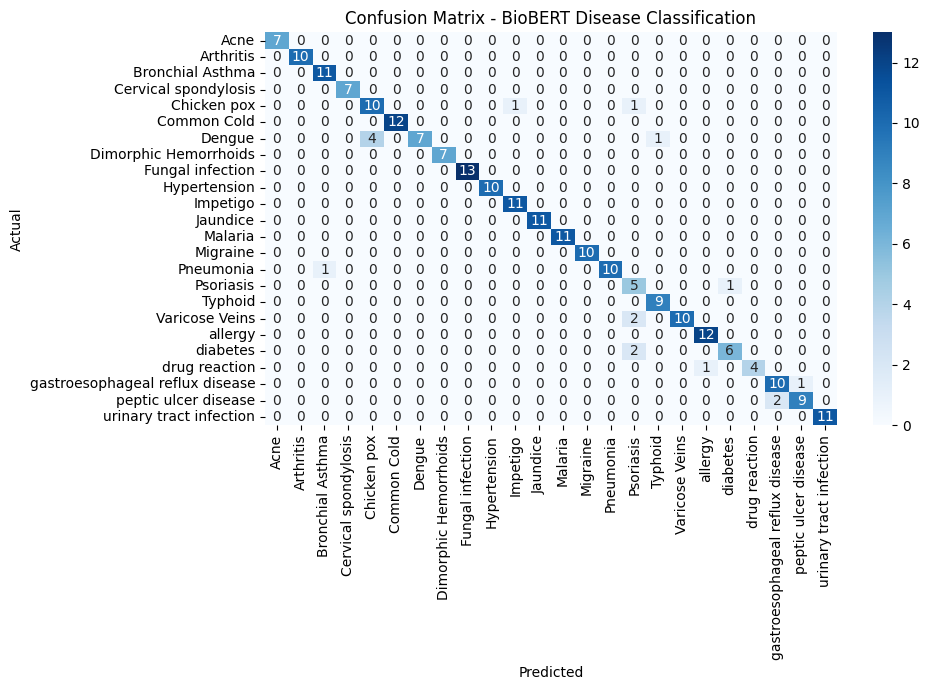

In [59]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - BioBERT Disease Classification')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
model.save_pretrained('./biobert_symptom_model')
tokenizer.save_pretrained('./biobert_symptom_model')

In [60]:

model.save_pretrained('./biobert_symptom_model')
tokenizer.save_pretrained('./biobert_symptom_model')


import pickle
with open('./biobert_symptom_model/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)


import shutil
shutil.make_archive('biobert_symptom_model', 'zip', './biobert_symptom_model')


from google.colab import files
files.download('biobert_symptom_model.zip')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>